# 04 - Single-Dataset Latent Simulator

Configure one dataset, train the shared autoencoder and latent propagator, then identify which physical deformation variables the latent trajectory encodes and inspect autoregressive rollout quality.


In [17]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from lss.latent.analysis import framewise_latent_descriptor_sweep
from lss.latent.experiment import (
    initial_latent_analysis,
    prepare_source_spec,
    result_tables,
    rollout_curve_summary,
    save_result_tables,
    seed_everything,
    train_latent_experiment,
)
from lss.latent.simulation import pearson_r, r2_score
from lss.utils import resolve_device

plt.rcParams['figure.dpi'] = 110


## Configuration


In [ ]:
seed = random.SystemRandom().randrange(1, 2**31)
seed_everything(seed)
print('run seed:', seed)

selected_dataset = 'reid'

dataset_specs = {
    'reid': {
        'label': 'Reid',
        'path': '../../data/new_reid_combined.pt',
        'train_count': 10,
        'val_count': 10,
    },
    'depablo': {
        'label': 'dePablo',
        'path': '../../data/2340_dePablo_networks_OOL_undirected.pt',
        'train_count': 30,
        'val_count': 25,
    },
    'depablo-10k-mix-temp': {
        'label': 'dePablo 10k mixed temperature',
        'path': 'data/depablo-10k-mix-temp.pt',
        'train_count': 80,
        'val_count': 50,
    },
    'noizy': {
        'label': 'Noizy',
        'path': 'data/200_rand_pruned_OOL_bidirect_val1057.pt',
        'train_count': 80,
        'val_count': 20,
    },
    
}

cfg = {
    'dataset_name': selected_dataset,
    'split_seed': seed,
    # Balance temperature groups only when the selected dataset provides them.
    'split_stratify_temperature': selected_dataset == 'depablo-10k-mix-temp',
    'min_train_p_ratio': None,
    'device': 'auto',
    'pos_dim': 2,
    'batch_graphs': 4,
    'frame_skip': 1,
    # Include the undeformed state because every rollout starts from frame 0.
    'train_frame_start_order': 0,
    'latent_dim': 2,
    'latent_tokens': 16,
    'hidden_size': 64,
    'edge_feature_dim': 8,
    # Cover the nonlinear transient and the rollout range being evaluated.
    'ae_max_train_frames_per_sim': 100,
    'dyn_max_train_transitions_per_sim': 100,
    'ae_target_mode': 'delta',
    'node_feature_mode': 'delta',
    # Preserve vertical motion, which together with horizontal compression controls p-ratio.
    'ae_coordinate_weights': [1.0, 2.0],
    'ae_max_epochs': 300,
    'ae_patience': 5,
    'ae_lr': 1e-4,
    'ae_weight_decay': 1e-5,
    'dyn_max_epochs': 300,
    'dyn_patience': 5,
    'dyn_lr': 1e-4,
    'dyn_weight_decay': 1e-5,
    'propagator_loss': 'delta',
    'propagator_objective': 'one_step',
    # Condition every latent update on reference geometry, topology and stiffness.
    'propagator_use_static_context': True,
    'graph_context_dim': 16,
    'propagator_context_include_temperature': False,
    # The propagator learns z(t) -> z(t+k); rollout horizons remain physical frame counts.
    'propagator_step_stride': 1,
    'initial_velocity': 'zero',
    'propagator_model': None,
    'early_stop_min_delta': 1e-5,
    'rollout_steps_grid': [10, 20, 50, 100, 150, 300],
    'temperature_pratio_window': 'full',
    # Use evenly spaced frames for the interpretation sweep; first/final are retained.
    'descriptor_max_frames_per_sim': 60,
    'output_root': '../results/latent_space_simulator_single_dataset',
}

device = resolve_device(cfg['device'])
source_spec = prepare_source_spec(selected_dataset, dataset_specs, cfg, seed=seed)
run_dir = Path(cfg['output_root']) / selected_dataset / 'cv16_temperature_context'
run_dir.mkdir(parents=True, exist_ok=True)

print('dataset:', selected_dataset)
print('path:', source_spec['path'])
print('device:', device)
print('output:', run_dir)
display(pd.DataFrame([source_spec]))


run seed: 573187811
dataset: noizy
path: /home/alexz/Documents/course_project/data/200_rand_pruned_OOL_bidirect_val1057.pt
device: cuda
output: ../results/latent_space_simulator_single_dataset/noizy/cv16_temperature_context


,label,path,train_count,val_count,source_name,dataset_name,target_mode,ae_target_mode,node_feature_mode,latent_dim,...,ae_max_train_frames_per_sim,dyn_max_train_transitions_per_sim,ae_max_epochs,ae_patience,ae_lr,ae_weight_decay,dyn_max_epochs,dyn_patience,dyn_lr,dyn_weight_decay
0,Noizy CV2 delta,/home/alexz/Documents/course_project/data/200_...,80,20,Noizy,noizy,delta,delta,delta,2,...,100,100,300,5,0.0001,0.00001,300,5,0.0001,0.00001


## Train Autoencoder And Latent Propagator



=== Noizy CV2 delta ===
                              source                                                                              path  total  train  val  test
200_rand_pruned_OOL_bidirect_val1057 /home/alexz/Documents/course_project/data/200_rand_pruned_OOL_bidirect_val1057.pt    200     80   20   100
autoencoder
ae 0001 train=0.729949 val=0.899326 stale=0
ae 0002 train=0.688911 val=0.888682 stale=0
ae 0004 train=0.651421 val=0.865862 stale=0
latent propagator: objective=one_step step_stride=1 train_rows=8000 val_rows=2000
propagator 0001 train=0.423734 val=0.440533 stale=0
propagator 0002 train=0.176937 val=0.393304 stale=0
propagator 0003 train=0.145179 val=0.389224 stale=0
propagator 0004 train=0.12642 val=0.364058 stale=0
rollout eval split=train: 6 horizons up to 300
rollout eval split=val: 6 horizons up to 300
rollout eval split=test: 6 horizons up to 300


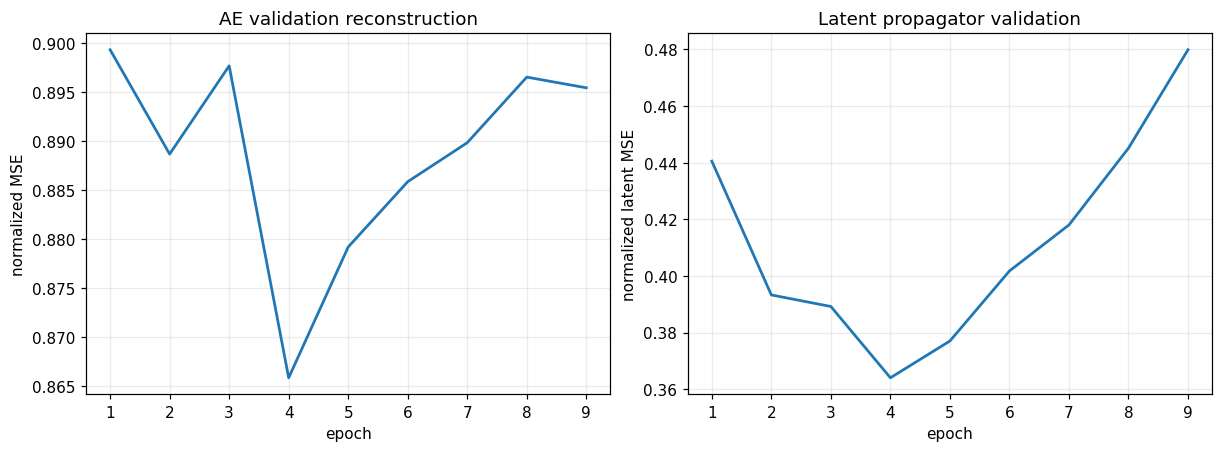

AE-only teacher-forced reconstruction (no propagator)


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,transverse_pos_mse,latent_dim,repeat_idx,model_seed,run_label
0,Noizy CV2 delta,val,10,20,-0.476430,0.603407,0.020744,0.000003,0.000006,0.000010,1.580075,0.486164,0.513836,0.000002,2,1,573189829,Noizy CV2 delta
1,Noizy CV2 delta,val,20,20,0.456790,0.769884,0.014179,0.000010,0.000028,0.000019,0.705171,0.353167,0.646833,0.000008,2,1,573189829,Noizy CV2 delta
2,Noizy CV2 delta,val,50,20,0.836223,0.918217,0.008052,0.000098,0.000215,0.000111,0.516747,0.452882,0.547118,0.000091,2,1,573189829,Noizy CV2 delta
3,Noizy CV2 delta,val,100,20,0.753047,0.904073,0.016043,0.000609,0.001064,0.000379,0.356748,0.573005,0.426995,0.000587,2,1,573189829,Noizy CV2 delta
4,Noizy CV2 delta,val,150,20,-0.164596,0.778661,0.079882,0.001902,0.002666,0.000860,0.322599,0.713274,0.286726,0.001894,2,1,573189829,Noizy CV2 delta
5,Noizy CV2 delta,val,300,20,-0.607118,0.679107,0.122138,0.009706,0.011079,0.004847,0.437515,0.876095,0.123905,0.010044,2,1,573189829,Noizy CV2 delta
6,Noizy CV2 delta,test,10,100,-1.351686,0.304142,0.035934,0.000004,0.000006,0.000011,1.839911,0.575593,0.424407,0.000002,2,1,573189829,Noizy CV2 delta
7,Noizy CV2 delta,test,20,100,-0.036811,0.534249,0.024159,0.000010,0.000027,0.000022,0.801557,0.372437,0.627563,0.000009,2,1,573189829,Noizy CV2 delta
8,Noizy CV2 delta,test,50,100,0.671329,0.840805,0.012409,0.000094,0.000207,0.000109,0.527802,0.457056,0.542944,0.000085,2,1,573189829,Noizy CV2 delta
9,Noizy CV2 delta,test,100,100,0.646503,0.868617,0.019737,0.000550,0.000982,0.000355,0.361640,0.559841,0.440159,0.000505,2,1,573189829,Noizy CV2 delta


,dataset,split,rollout_steps,used,p_ratio_r2,p_ratio_pearson,p_ratio_mse,final_pos_mse,initial_to_target_mse,pred_to_initial_mse,movement_fraction_mse,rollout_error_fraction,rollout_position_r2,latent_dim,repeat_idx,model_seed,run_label
0,Noizy CV2 delta,train,10,80,-1.80123,0.21330,0.04274,0.00000,0.00001,0.00001,1.75268,0.49992,0.50008,2,1,573189829,Noizy CV2 delta
1,Noizy CV2 delta,train,20,80,-0.39087,0.34015,0.03500,0.00001,0.00003,0.00002,0.82229,0.34428,0.65572,2,1,573189829,Noizy CV2 delta
2,Noizy CV2 delta,train,50,80,0.12335,0.49934,0.03857,0.00009,0.00020,0.00011,0.55970,0.43689,0.56311,2,1,573189829,Noizy CV2 delta
3,Noizy CV2 delta,train,100,80,-0.03681,0.54367,0.06203,0.00049,0.00093,0.00037,0.39690,0.53026,0.46974,2,1,573189829,Noizy CV2 delta
4,Noizy CV2 delta,train,150,80,-0.10825,0.50598,0.07236,0.00146,0.00230,0.00095,0.41486,0.63704,0.36296,2,1,573189829,Noizy CV2 delta
5,Noizy CV2 delta,train,300,80,-0.15179,0.37245,0.08523,0.25955,0.01022,0.29701,29.05498,25.39045,0.00000,2,1,573189829,Noizy CV2 delta
6,Noizy CV2 delta,val,10,20,-1.76350,0.47306,0.03883,0.00000,0.00001,0.00001,1.48075,0.50098,0.49902,2,1,573189829,Noizy CV2 delta
7,Noizy CV2 delta,val,20,20,-0.46341,0.37306,0.03820,0.00001,0.00003,0.00002,0.66823,0.39979,0.60021,2,1,573189829,Noizy CV2 delta
8,Noizy CV2 delta,val,50,20,-0.52186,0.22714,0.07482,0.00011,0.00022,0.00009,0.43018,0.50706,0.49294,2,1,573189829,Noizy CV2 delta
9,Noizy CV2 delta,val,100,20,-1.35520,0.18554,0.15300,0.00067,0.00106,0.00034,0.32177,0.62671,0.37329,2,1,573189829,Noizy CV2 delta


In [19]:
seed_everything(source_spec['model_seed'])
result = train_latent_experiment(source_spec, cfg, device=device)
results = [result]

tables = result_tables(results)
save_result_tables(tables, run_dir)

ae_history_df = tables['ae_history']
dyn_history_df = tables['dyn_history']
rollout_rows_df = tables['rollout_rows']
rollout_stats_df = tables['rollout_stats']
ae_reconstruction_rows_df = tables['ae_reconstruction_rows']
ae_reconstruction_stats_df = tables['ae_reconstruction_stats']

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(ae_history_df['epoch'], ae_history_df['val_mse_norm'], lw=1.8)
axes[0].set(title='AE validation reconstruction', xlabel='epoch', ylabel='normalized MSE')
axes[1].plot(dyn_history_df['epoch'], dyn_history_df['val_dz_mse_norm'], lw=1.8)
axes[1].set(title='Latent propagator validation', xlabel='epoch', ylabel='normalized latent MSE')
for ax in axes:
    ax.grid(alpha=0.25)
plt.show()

print('AE-only teacher-forced reconstruction (no propagator)')
display(ae_reconstruction_stats_df.round(6))

display(rollout_stats_df.round(5))


## Initial Latent P-Ratio Baseline

This is retained as a diagnostic, not as the primary interpretation. If the initial latent does not generalize to final p-ratio, the trajectory descriptor sweep below determines what the representation actually encodes.


No varying temperature metadata; skipping temperature-adjusted readouts.


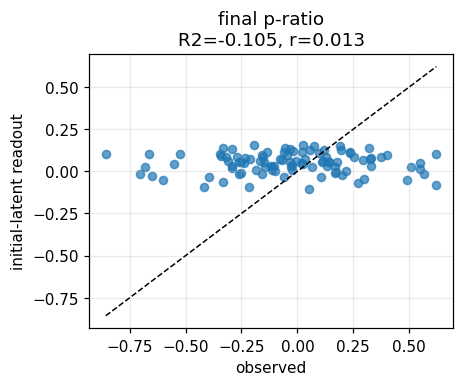

Linear combination used all coordinates: z0, z1
final p-ratio: test R2=-0.105, r=0.013


In [20]:
latent_df, latent_corr_df = initial_latent_analysis(results, device=device)
latent_df.to_csv(run_dir / 'initial_latent_table.csv', index=False)
latent_corr_df.to_csv(run_dir / 'initial_latent_p_ratio_correlations.csv', index=False)

z_cols = sorted(
    [col for col in latent_df if col.startswith('z')],
    key=lambda col: int(col[1:]),
)
val_latent = latent_df[latent_df['split'].eq('val')].copy()
test_latent = latent_df[latent_df['split'].eq('test')].copy()

targets = {
    'final_p_ratio': 'final p-ratio',
}
temp_val_raw = val_latent['temperature'].to_numpy(float)
temp_test_raw = test_latent['temperature'].to_numpy(float)
has_temperature = (
    np.isfinite(temp_val_raw).all()
    and np.isfinite(temp_test_raw).all()
    and np.unique(temp_val_raw).size > 1
)
if has_temperature:
    # Ask whether z contains response information beyond temperature.
    temp_val = np.log1p(temp_val_raw)
    temp_test = np.log1p(temp_test_raw)
    temp_design_val = np.column_stack([np.ones(len(temp_val)), temp_val])
    temp_coef = np.linalg.lstsq(
        temp_design_val, val_latent['final_p_ratio'].to_numpy(float), rcond=None,
    )[0]
    val_latent['temperature_adjusted_p_ratio'] = (
        val_latent['final_p_ratio'] - temp_design_val @ temp_coef
    )
    test_latent['temperature_adjusted_p_ratio'] = (
        test_latent['final_p_ratio']
        - np.column_stack([np.ones(len(temp_test)), temp_test]) @ temp_coef
    )
    targets.update({
        'temperature': 'temperature',
        'temperature_adjusted_p_ratio': 'temp-adjusted p-ratio',
    })
else:
    print('No varying temperature metadata; skipping temperature-adjusted readouts.')
X_val = val_latent[z_cols].to_numpy(float)
X_test = test_latent[z_cols].to_numpy(float)
x_mean = X_val.mean(axis=0)
x_std = X_val.std(axis=0) + 1e-12
design_val = np.column_stack([np.ones(len(X_val)), (X_val - x_mean) / x_std])
design_test = np.column_stack([np.ones(len(X_test)), (X_test - x_mean) / x_std])

readout_rows = []
weight_rows = []
test_predictions = {}
for target, label in targets.items():
    y_val = val_latent[target].to_numpy(float)
    y_test = test_latent[target].to_numpy(float)
    coef = np.linalg.lstsq(design_val, y_val, rcond=None)[0]
    pred = design_test @ coef
    test_predictions[target] = pred
    readout_rows.append({
        'target': label,
        'test_r2': r2_score(y_test, pred),
        'test_pearson_r': pearson_r(y_test, pred),
    })
    weight_rows.append({
        'target': label,
        'intercept': float(coef[0] - np.sum(coef[1:] * x_mean / x_std)),
        **{f'{col}_weight': float(weight) for col, weight in zip(z_cols, coef[1:] / x_std)},
    })

latent_readout_df = pd.DataFrame(readout_rows)
latent_readout_weights_df = pd.DataFrame(weight_rows)
latent_readout_df.to_csv(run_dir / 'initial_latent_linear_readout_scores.csv', index=False)
latent_readout_weights_df.to_csv(run_dir / 'initial_latent_linear_readout_weights.csv', index=False)

fig, axes = plt.subplots(
    1, len(targets), figsize=(4.1 * len(targets), 3.4), constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, (target, label) in zip(axes, targets.items()):
    observed = test_latent[target].to_numpy(float)
    predicted = test_predictions[target]
    score = latent_readout_df.loc[latent_readout_df['target'].eq(label)].iloc[0]
    ax.scatter(observed, predicted, s=28, alpha=0.7, color='tab:blue')
    finite = np.isfinite(observed) & np.isfinite(predicted)
    if finite.any():
        lo = min(observed[finite].min(), predicted[finite].min())
        hi = max(observed[finite].max(), predicted[finite].max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    ax.set(
        title=f'{label}\nR2={score.test_r2:.3f}, r={score.test_pearson_r:.3f}',
        xlabel='observed', ylabel='initial-latent readout',
    )
    ax.grid(alpha=0.25)
plt.show()

print('Linear combination used all coordinates:', ', '.join(z_cols))
for row in latent_readout_df.itertuples(index=False):
    print(f'{row.target}: test R2={row.test_r2:.3f}, r={row.test_pearson_r:.3f}')


## Example Node Motion During Compression

For one held-out network, select representative nodes near the left, center, right, top, and bottom. The small plots show each node's position change as the network's horizontal strain changes. Horizontal strain here means `(current width - initial width) / initial width`; negative values are compression.


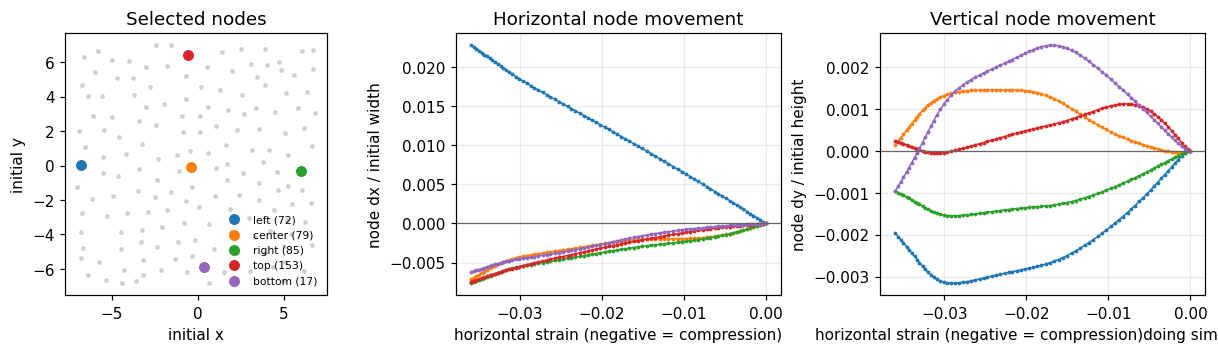

In [21]:
motion_sim = result['test_data'][0]
ref_pos = motion_sim[0].x[:, :2].detach().cpu().numpy()
ref_min = ref_pos.min(axis=0)
ref_span = np.maximum(np.ptp(ref_pos, axis=0), 1e-12)
ref_unit = (ref_pos - ref_min) / ref_span

node_targets = {
    'left': (0.05, 0.50),
    'center': (0.50, 0.50),
    'right': (0.95, 0.50),
    'top': (0.50, 0.95),
    'bottom': (0.50, 0.05),
}
selected_nodes = {}
used_nodes = set()
for label, target in node_targets.items():
    distance = np.sum((ref_unit - np.asarray(target)) ** 2, axis=1)
    for node_idx in np.argsort(distance):
        node_idx = int(node_idx)
        if node_idx not in used_nodes:
            selected_nodes[label] = node_idx
            used_nodes.add(node_idx)
            break

frame_count = min(len(motion_sim), 80)
frame_ids = np.unique(np.linspace(0, len(motion_sim) - 1, frame_count, dtype=int))
horizontal_strain = []
node_dx = {label: [] for label in selected_nodes}
node_dy = {label: [] for label in selected_nodes}
for frame_idx in frame_ids:
    pos = motion_sim[int(frame_idx)].x[:, :2].detach().cpu().numpy()
    horizontal_strain.append(np.ptp(pos[:, 0]) / ref_span[0] - 1.0)
    for label, node_idx in selected_nodes.items():
        node_dx[label].append((pos[node_idx, 0] - ref_pos[node_idx, 0]) / ref_span[0])
        node_dy[label].append((pos[node_idx, 1] - ref_pos[node_idx, 1]) / ref_span[1])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.1), constrained_layout=True)
axes[0].scatter(ref_pos[:, 0], ref_pos[:, 1], s=5, color='0.75', alpha=0.6)
for label, node_idx in selected_nodes.items():
    axes[0].scatter(*ref_pos[node_idx], s=38, label=f'{label} ({node_idx})')
axes[0].set(title='Selected nodes', xlabel='initial x', ylabel='initial y', aspect='equal')
axes[0].legend(fontsize=7, frameon=False)

for label in selected_nodes:
    axes[1].plot(horizontal_strain, node_dx[label], marker='.', ms=3, lw=1, label=label)
    axes[2].plot(horizontal_strain, node_dy[label], marker='.', ms=3, lw=1, label=label)
axes[1].set(
    title='Horizontal node movement',
    xlabel='horizontal strain (negative = compression)',
    ylabel='node dx / initial width',
)
axes[2].set(
    title='Vertical node movement',
    xlabel='horizontal strain (negative = compression)doing simulation',
    ylabel='node dy / initial height',
)
for ax in axes[1:]:
    ax.axhline(0, color='0.4', lw=0.8)
    ax.grid(alpha=0.25)
plt.show()


## What The Latent Trajectory Encodes

Sweep horizontal and vertical node motion, normalized box-size changes, average edge-length change, motion not explained by uniform box deformation, and an elastic-energy proxy. Every linear combination is fitted on validation networks and scored on held-out test networks.


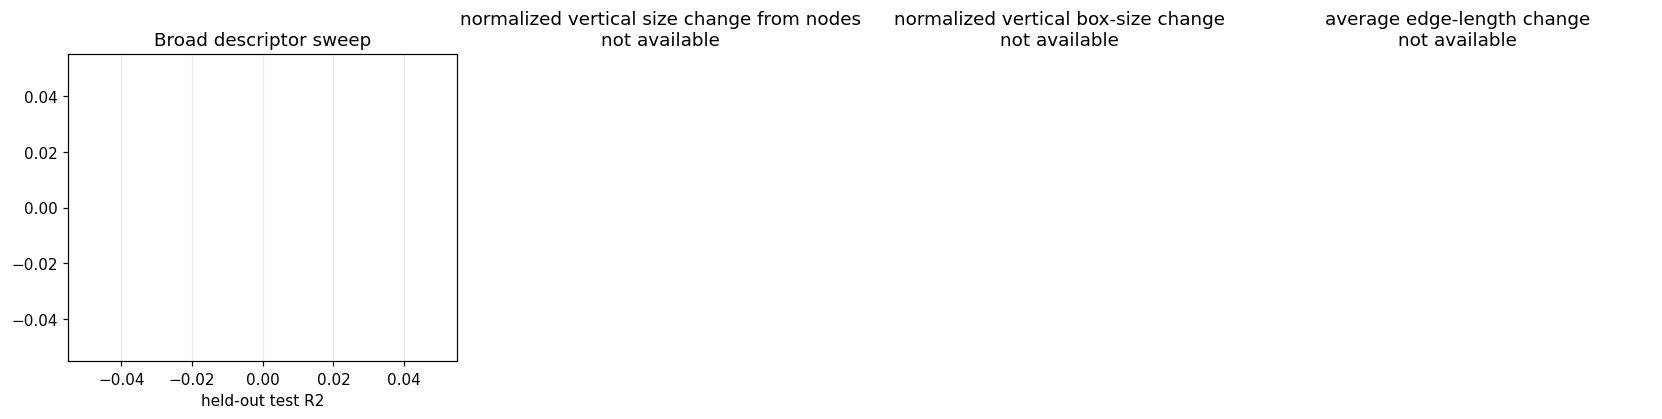

Strongest held-out latent-state readouts


In [22]:
descriptor_frame_df, descriptor_score_df, descriptor_prediction_df, descriptor_weight_df = (
    framewise_latent_descriptor_sweep(
        result,
        device=device,
        frame_stride=1,
        max_frames_per_sim=cfg.get('descriptor_max_frames_per_sim', 60),
    )
)
descriptor_score_df.to_csv(run_dir / 'framewise_latent_descriptor_scores.csv', index=False)
descriptor_weight_df.to_csv(run_dir / 'framewise_latent_descriptor_weights.csv', index=False)

target_labels = {
    'affine_yy': 'normalized vertical size change from nodes',
    'box_strain_y': 'normalized vertical box-size change',
    'box_area_strain': 'normalized box-area change',
    'affine_xx': 'normalized horizontal size change from nodes',
    'rms_dx': 'horizontal node-motion magnitude',
    'edge_stretch_mean': 'average edge-length change',
    'edge_rel_stretch_mean': 'average normalized edge-length change',
    'rms_disp': 'total node-motion magnitude',
    'nonaffine_rms': 'non-uniform node-motion magnitude',
    'spring_energy_proxy': 'spring-energy proxy',
    'frame_progress': 'trajectory progress',
}
state_scores = (
    descriptor_score_df[descriptor_score_df['feature_set'].eq('latent state')]
    .sort_values('test_r2', ascending=False)
)
plot_scores = state_scores.head(8).sort_values('test_r2')

fig, axes = plt.subplots(1, 4, figsize=(15, 3.7), constrained_layout=True)
axes[0].barh(
    [target_labels.get(target, target) for target in plot_scores['target']],
    plot_scores['test_r2'], color='tab:blue', alpha=0.8,
)
axes[0].set(title='Broad descriptor sweep', xlabel='held-out test R2')
axes[0].grid(axis='x', alpha=0.25)

detail_targets = ['affine_yy', 'box_strain_y', 'edge_stretch_mean']
descriptor_temperatures = descriptor_prediction_df['temperature'].to_numpy(float)
color_by_temperature = np.isfinite(descriptor_temperatures).any()
temperature_points = None
for ax, target in zip(axes[1:], detail_targets):
    sub = descriptor_prediction_df[
        descriptor_prediction_df['feature_set'].eq('latent state')
        & descriptor_prediction_df['target'].eq(target)
    ]
    score_rows = state_scores.loc[state_scores['target'].eq(target), 'test_r2']
    if sub.empty or score_rows.empty:
        ax.set(title=f'{target_labels[target]}\nnot available')
        ax.axis('off')
        continue
    scatter_kwargs = {'c': sub['temperature'], 'cmap': 'viridis'} if color_by_temperature else {'color': 'tab:blue'}
    points = ax.scatter(
        sub['observed'], sub['predicted'], s=8, alpha=0.22,
        rasterized=True, **scatter_kwargs,
    )
    if color_by_temperature:
        temperature_points = points
    lo, hi = np.nanmin(np.r_[sub['observed'], sub['predicted']]), np.nanmax(np.r_[sub['observed'], sub['predicted']])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    score = score_rows.iloc[0]
    ax.set(
        title=f'{target_labels[target]}\nR2={score:.3f}',
        xlabel='observed', ylabel='latent readout',
    )
    ax.grid(alpha=0.25)
if temperature_points is not None:
    fig.colorbar(temperature_points, ax=axes[1:], pad=0.01, label='temperature')
plt.show()

print('Strongest held-out latent-state readouts')
for row in state_scores.head(10).itertuples(index=False):
    label = target_labels.get(row.target, row.target)
    print(
        f'{label}: test R2={row.test_r2:.3f}, '
        f'mean within-network r={row.mean_within_network_r:.3f}'
    )


### Interpretation

The latent trajectory primarily records **how the network changes shape**. It strongly predicts normalized vertical size change (`dy / initial height`), normalized horizontal size change (`dx / initial width`), box-area change, node-motion magnitude, and average edge-length change. These correlations remain strong within individual test trajectories, so they are not explained only by temperature or network identity.

It is much weaker at describing irregular local motion: node motion left after removing the best uniform shape change is only partially represented, while variation in edge-length changes and the spring-energy proxy are poorly predicted across networks. Therefore the latent should be interpreted as encoding the smooth overall shape-change path rather than detailed local elastic behavior.


## P-Ratio Along The Trajectory

P-ratio is calculated from normalized vertical and horizontal size changes: `-(dy / initial height) / (dx / initial width)`. We therefore compare direct latent-to-p-ratio fits with a physical two-step calculation: use the latent to predict normalized `dx` and `dy`, then calculate p-ratio from those predicted trajectories. Cumulative and rolling definitions test how much temporal averaging is required before the ratio becomes stable.


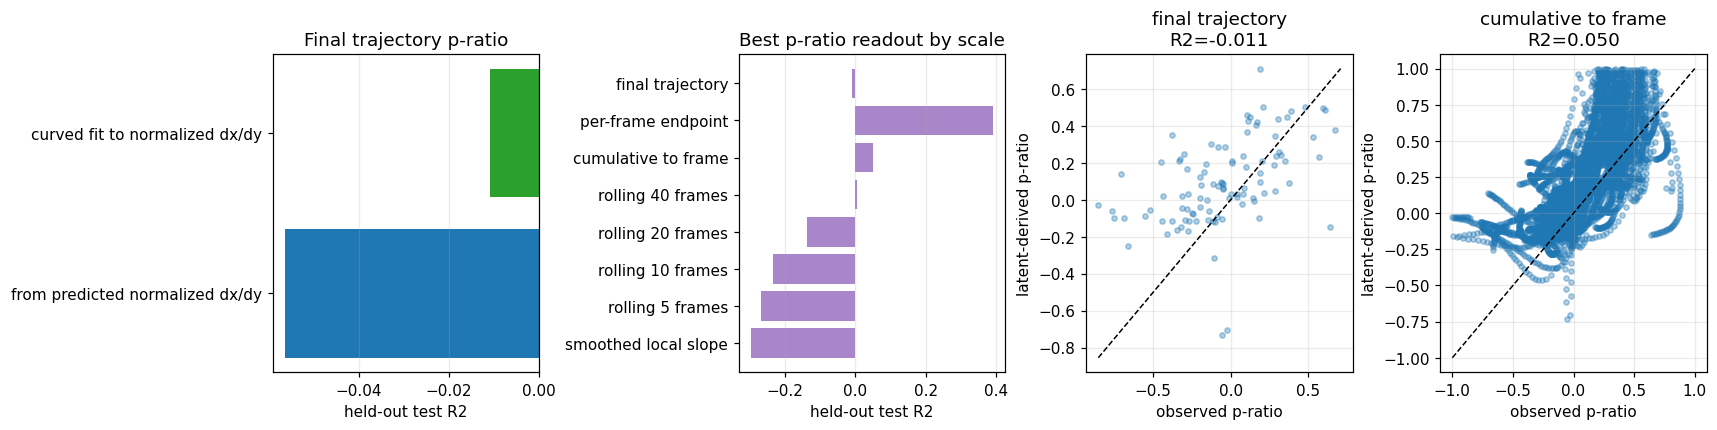

Best held-out p-ratio readouts
final trajectory: R2=-0.011 using curved latent state via predicted normalized dx/dy
per-frame endpoint: R2=0.392 using curved latent state via predicted normalized dx/dy
cumulative to frame: R2=0.050 using curved latent state via predicted normalized dx/dy
rolling 40 frames: R2=0.004 using curved latent state via predicted normalized dx/dy
rolling 20 frames: R2=-0.137 using curved latent state via predicted normalized dx/dy
rolling 10 frames: R2=-0.234 using latent state via predicted normalized dx/dy
rolling 5 frames: R2=-0.267 using latent state via predicted normalized dx/dy
smoothed local slope: R2=-0.297 using latent state via predicted normalized dx/dy


In [23]:
p_ratio_labels = {
    'side_final_trajectory_p_ratio': 'final trajectory',
    'side_endpoint_p_ratio': 'per-frame endpoint',
    'side_cumulative_p_ratio': 'cumulative to frame',
    'side_rolling_40_p_ratio': 'rolling 40 frames',
    'side_rolling_20_p_ratio': 'rolling 20 frames',
    'side_rolling_10_p_ratio': 'rolling 10 frames',
    'side_rolling_5_p_ratio': 'rolling 5 frames',
    'side_local_p_ratio': 'smoothed local slope',
}
p_ratio_scores = descriptor_score_df[
    descriptor_score_df['target'].isin(p_ratio_labels)
].copy()
best_by_target = (
    p_ratio_scores.sort_values('test_r2', ascending=False)
    .drop_duplicates('target')
)

final_methods = [
    'latent state',
    'quadratic latent state',
    'latent state via side strains',
    'quadratic latent state via side strains',
]
final_comparison = p_ratio_scores[
    p_ratio_scores['target'].eq('side_final_trajectory_p_ratio')
    & p_ratio_scores['feature_set'].isin(final_methods)
].set_index('feature_set').reindex(final_methods).reset_index()

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.8), constrained_layout=True)
method_labels = [
    'direct linear', 'direct curved fit',
    'from predicted normalized dx/dy',
    'curved fit to normalized dx/dy',
]
axes[0].barh(method_labels, final_comparison['test_r2'], color=['0.55', '0.4', 'tab:blue', 'tab:green'])
axes[0].set(title='Final trajectory p-ratio', xlabel='held-out test R2')
axes[0].grid(axis='x', alpha=0.25)

timescale_order = [
    'side_local_p_ratio', 'side_rolling_5_p_ratio', 'side_rolling_10_p_ratio',
    'side_rolling_20_p_ratio', 'side_rolling_40_p_ratio',
    'side_cumulative_p_ratio', 'side_endpoint_p_ratio',
    'side_final_trajectory_p_ratio',
]
timescale_scores = best_by_target.set_index('target').reindex(timescale_order).dropna(subset=['test_r2'])
axes[1].barh(
    [p_ratio_labels[target] for target in timescale_scores.index],
    timescale_scores['test_r2'], color='tab:purple', alpha=0.8,
)
axes[1].set(title='Best p-ratio readout by scale', xlabel='held-out test R2')
axes[1].grid(axis='x', alpha=0.25)

scatter_specs = [
    ('side_final_trajectory_p_ratio', 'quadratic latent state via side strains'),
    ('side_cumulative_p_ratio', 'quadratic latent state via side strains'),
]
p_ratio_temperatures = descriptor_prediction_df['temperature'].to_numpy(float)
color_by_temperature = np.isfinite(p_ratio_temperatures).any()
temperature_points = None
for ax, (target, feature_set) in zip(axes[2:], scatter_specs):
    sub = descriptor_prediction_df[
        descriptor_prediction_df['target'].eq(target)
        & descriptor_prediction_df['feature_set'].eq(feature_set)
    ].copy()
    if target == 'side_final_trajectory_p_ratio':
        sub = sub.drop_duplicates('sim_idx')
    score_rows = p_ratio_scores.loc[
        p_ratio_scores['target'].eq(target)
        & p_ratio_scores['feature_set'].eq(feature_set),
        'test_r2',
    ]
    if sub.empty or score_rows.empty:
        ax.set(title=f'{p_ratio_labels[target]}\nnot available')
        ax.axis('off')
        continue
    scatter_kwargs = {'c': sub['temperature'], 'cmap': 'viridis'} if color_by_temperature else {'color': 'tab:blue'}
    points = ax.scatter(
        sub['observed'], sub['predicted'], s=12, alpha=0.35,
        rasterized=True, **scatter_kwargs,
    )
    if color_by_temperature:
        temperature_points = points
    lo, hi = np.nanmin(np.r_[sub['observed'], sub['predicted']]), np.nanmax(np.r_[sub['observed'], sub['predicted']])
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
    score = score_rows.iloc[0]
    ax.set(
        title=f'{p_ratio_labels[target]}\nR2={score:.3f}',
        xlabel='observed p-ratio', ylabel='latent-derived p-ratio',
    )
    ax.grid(alpha=0.25)
if temperature_points is not None:
    fig.colorbar(temperature_points, ax=axes[2:], pad=0.01, label='temperature')
plt.show()

print('Best held-out p-ratio readouts')
for target in timescale_order[::-1]:
    row = best_by_target[best_by_target['target'].eq(target)]
    if row.empty:
        continue
    row = row.iloc[0]
    method = row.feature_set.replace('side strains', 'predicted normalized dx/dy')
    method = method.replace('quadratic', 'curved')
    print(f'{p_ratio_labels[target]}: R2={row.test_r2:.3f} using {method}')


## Autoregressive Rollout


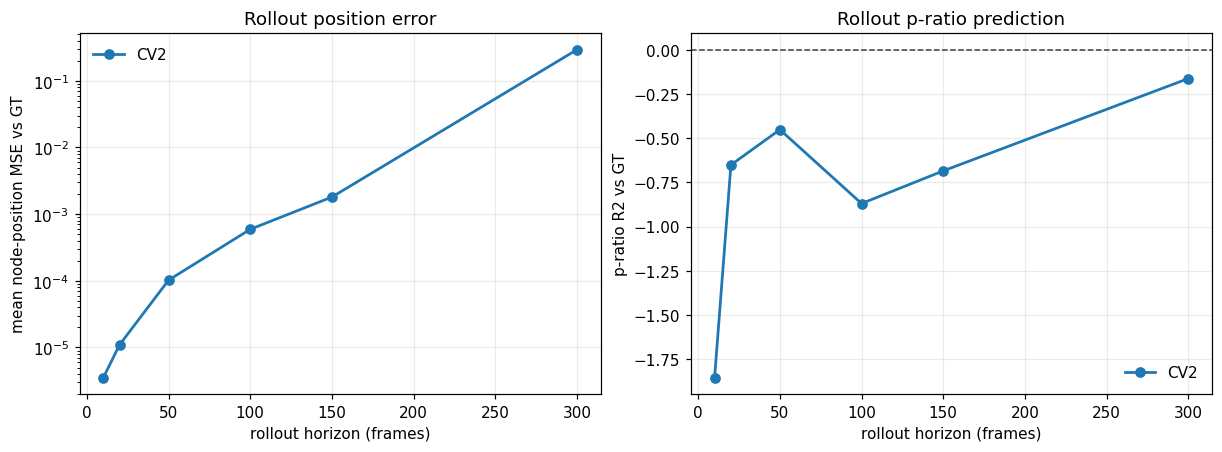

,latent_dim,split,rollout_steps,final_pos_mse,p_ratio_mse,used,p_ratio_r2,p_ratio_pearson
0,2,test,10,0.000004,0.043617,100,-1.854494,0.154676
1,2,test,20,0.000011,0.038473,100,-0.651134,0.158171
2,2,test,50,0.000102,0.054809,100,-0.451671,0.161559
3,2,test,100,0.000593,0.104377,100,-0.869406,0.173120
4,2,test,150,0.001805,0.120617,100,-0.684909,0.181278
5,2,test,300,0.292699,0.106681,100,-0.163134,0.186240


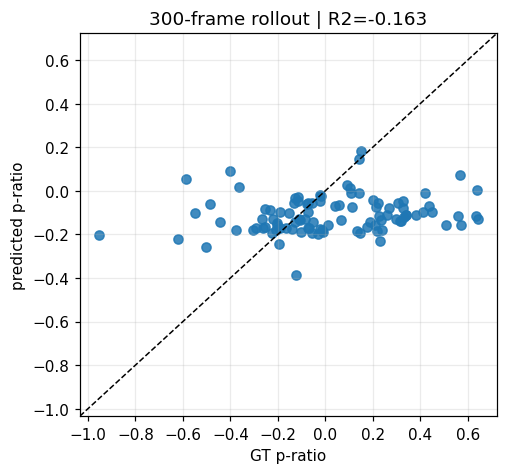

In [24]:
rollout_by_repeat_df, rollout_curve_df = rollout_curve_summary(rollout_rows_df)
rollout_by_repeat_df.to_csv(run_dir / 'rollout_error_vs_steps_by_repeat.csv', index=False)
rollout_curve_df.to_csv(run_dir / 'rollout_error_vs_steps.csv', index=False)

test_curve = rollout_curve_df[rollout_curve_df['split'].eq('test')].sort_values('rollout_steps')
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for latent_dim, group in test_curve.groupby('latent_dim'):
    label = f'CV{int(latent_dim)}'
    axes[0].plot(group['rollout_steps'], group['final_pos_mse'], marker='o', lw=1.8, label=label)
    axes[1].plot(group['rollout_steps'], group['p_ratio_r2'], marker='o', lw=1.8, label=label)
axes[0].set(
    title='Rollout position error',
    xlabel='rollout horizon (frames)',
    ylabel='mean node-position MSE vs GT',
    yscale='log',
)
axes[1].set(
    title='Rollout p-ratio prediction',
    xlabel='rollout horizon (frames)',
    ylabel='p-ratio R2 vs GT',
)
axes[1].axhline(0, color='0.25', lw=1, ls='--')
for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(frameon=False)
plt.show()

display(test_curve.round(6))

if not rollout_rows_df.empty:
    chosen_step = int(rollout_rows_df.loc[rollout_rows_df['split'].eq('test'), 'rollout_steps'].max())
    scatter_df = rollout_rows_df[
        rollout_rows_df['split'].eq('test')
        & rollout_rows_df['rollout_steps'].eq(chosen_step)
    ]
    x = scatter_df['true_p_ratio'].to_numpy(float)
    y = scatter_df['pred_p_ratio'].to_numpy(float)
    lo, hi = np.nanmin(np.r_[x, y]), np.nanmax(np.r_[x, y])
    pad = 0.05 * max(hi - lo, 1e-6)

    fig, ax = plt.subplots(figsize=(4.5, 4.2), constrained_layout=True)
    temperatures = scatter_df['temperature'].to_numpy(float)
    if np.isfinite(temperatures).sum() and len(np.unique(temperatures[np.isfinite(temperatures)])) > 1:
        points = ax.scatter(x, y, c=temperatures, cmap='viridis', s=36, alpha=0.85)
        fig.colorbar(points, ax=ax, pad=0.02, label='temperature')
    else:
        ax.scatter(x, y, s=36, alpha=0.85)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], 'k--', lw=1)
    ax.set(
        xlim=(lo - pad, hi + pad), ylim=(lo - pad, hi + pad),
        title=f'{chosen_step}-frame rollout | R2={r2_score(x, y):.3f}',
        xlabel='GT p-ratio', ylabel='predicted p-ratio',
    )
    ax.grid(alpha=0.25)
    plt.show()
